In [ ]:
import kagglehub
import os
import shutil

# Download the REFUGE2 Glaucoma dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("victorlemosml/refuge2")
print(f"Dataset downloaded to: {path}")

# Copy to /content for easy access
dataset_copy_path = "/content/refuge2"
if os.path.exists(dataset_copy_path):
    shutil.rmtree(dataset_copy_path)
shutil.copytree(path, dataset_copy_path)

print(f"Dataset copied to: {dataset_copy_path}")
print("Contents of copied directory:", os.listdir(dataset_copy_path))


100%|██████████| 1.27G/1.27G [00:09<00:00, 146MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/victorlemosml/refuge2/versions/1
Dataset copied to: /content/refuge2
Contents of copied directory: ['REFUGE2']


In [ ]:
import kagglehub
import os
import shutil

# Download the ORIGA Glaucoma dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("sohamchakraborty2004/origa-glaucoma")
print(f"Dataset downloaded to: {path}")

# Copy to /content for easy access
dataset_copy_path = "/content/origa-glaucoma"
if os.path.exists(dataset_copy_path):
    shutil.rmtree(dataset_copy_path)
shutil.copytree(path, dataset_copy_path)

print(f"Dataset copied to: {dataset_copy_path}")
print("Contents of copied directory:", os.listdir(dataset_copy_path))


100%|██████████| 459M/459M [00:05<00:00, 82.9MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/sohamchakraborty2004/origa-glaucoma/versions/1
Dataset copied to: /content/origa-glaucoma
Contents of copied directory: ['ORIGA']


In [ ]:
import kagglehub
import os
import shutil

# Download the HRF Dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("realhaadkhan/hrf-dataset")
print(f"Dataset downloaded to: {path}")

# Copy to /content for easy access
dataset_copy_path = "/content/hrf-dataset"
if os.path.exists(dataset_copy_path):
    shutil.rmtree(dataset_copy_path)
shutil.copytree(path, dataset_copy_path)

print(f"Dataset copied to: {dataset_copy_path}")
print("Contents of copied directory:", os.listdir(dataset_copy_path))


100%|██████████| 39.1M/39.1M [00:00<00:00, 102MB/s] 

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/realhaadkhan/hrf-dataset/versions/1
Dataset copied to: /content/hrf-dataset
Contents of copied directory: ['HRF']


In [ ]:
import os
import shutil
import random
from glob import glob

# Paths to the downloaded datasets
refuge2_path = "/content/refuge2/REFUGE2"
origa_path = "/content/origa-glaucoma/ORIGA"
hrf_path = "/content/hrf-dataset/HRF"

# Destination master dataset path
master_path = "/content/master_dataset"

# Define final structure
for split in ["train", "test"]:
    for cls in ["glaucoma", "normal"]:
        os.makedirs(os.path.join(master_path, split, cls), exist_ok=True)

# Function to collect and label images
def collect_images(base_path):
    all_images = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg', '.tif', '.bmp')):
                full_path = os.path.join(root, file)
                # infer label based on folder name
                if "glaucoma" in root.lower() or "gl" in root.lower():
                    label = "glaucoma"
                else:
                    label = "normal"
                all_images.append((full_path, label))
    return all_images

# Collect all images from three datasets
refuge_images = collect_images(refuge2_path)
origa_images = collect_images(origa_path)
hrf_images = collect_images(hrf_path)

print(f"REFUGE2: {len(refuge_images)} images")
print(f"ORIGA: {len(origa_images)} images")
print(f"HRF: {len(hrf_images)} images")

# Merge all
all_images = refuge_images + origa_images + hrf_images
random.shuffle(all_images)

# Split 80/20 for train/test
split_idx = int(0.8 * len(all_images))
train_images = all_images[:split_idx]
test_images = all_images[split_idx:]

# Helper to copy files
def copy_images(image_list, split):
    for src, label in image_list:
        dst_dir = os.path.join(master_path, split, label)
        dst = os.path.join(dst_dir, os.path.basename(src))
        shutil.copy2(src, dst)

print("Copying training images...")
copy_images(train_images, "train")

print("Copying testing images...")
copy_images(test_images, "test")

print("✅ Merge completed successfully!")
for split in ["train", "test"]:
    for cls in ["glaucoma", "normal"]:
        path = os.path.join(master_path, split, cls)
        print(f"{split}/{cls}: {len(os.listdir(path))} images")


REFUGE2: 2400 images
ORIGA: 650 images
HRF: 30 images
Copying training images...
Copying testing images...
✅ Merge completed successfully!
train/glaucoma: 537 images
train/normal: 1927 images
test/glaucoma: 128 images
test/normal: 488 images


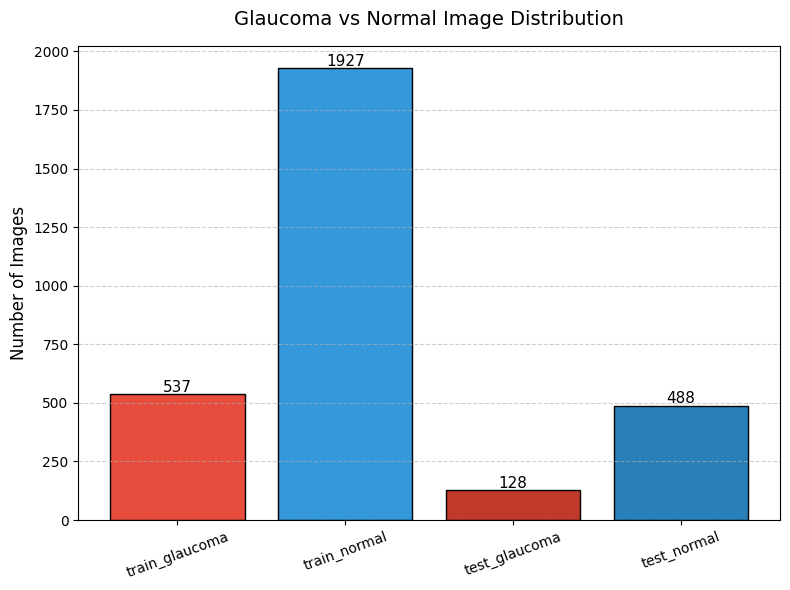

In [ ]:
import matplotlib.pyplot as plt
import os

# Define paths
base_dir = "/content/master_dataset"

# Count images in each class and split
def count_images(path):
    counts = {}
    for split in ["train", "test"]:
        for cls in ["glaucoma", "normal"]:
            folder = os.path.join(path, split, cls)
            counts[f"{split}_{cls}"] = len(os.listdir(folder))
    return counts

# Get counts
counts = count_images(base_dir)

# Prepare data for plotting
splits = ["train_glaucoma", "train_normal", "test_glaucoma", "test_normal"]
values = [counts[s] for s in splits]
colors = ['#E74C3C', '#3498DB', '#C0392B', '#2980B9']  # red shades for glaucoma, blue for normal

# Plot
plt.figure(figsize=(8,6))
bars = plt.bar(splits, values, color=colors, edgecolor='black')
plt.title("Glaucoma vs Normal Image Distribution", fontsize=14, pad=15)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=20, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add counts on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10, f"{height}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()


Before Augmentation:
Glaucoma images: 537
Normal images:   1927
Images to generate: 1390

Augmentation started...

✅ Augmentation completed!

After Augmentation:
Glaucoma images: 1830
Normal images:   1927


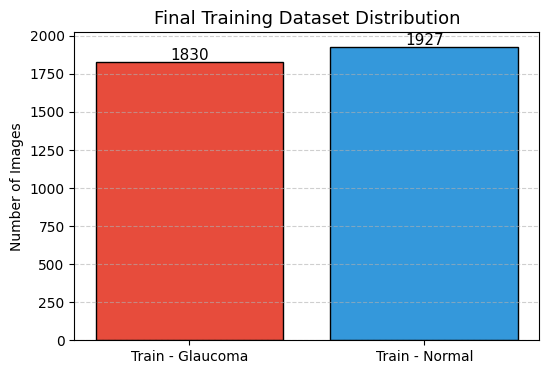

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import numpy as np
from glob import glob
import shutil
import matplotlib.pyplot as plt

# Paths
train_glaucoma_dir = "/content/master_dataset/train/glaucoma"
train_normal_dir = "/content/master_dataset/train/normal"

# Count current images
num_glaucoma = len(os.listdir(train_glaucoma_dir))
num_normal = len(os.listdir(train_normal_dir))

print(f"Before Augmentation:")
print(f"Glaucoma images: {num_glaucoma}")
print(f"Normal images:   {num_normal}")

# Difference to balance
target_count = num_normal  # we’ll make glaucoma count equal to normal
augment_needed = target_count - num_glaucoma
print(f"Images to generate: {augment_needed}")

# Create an augmentation generator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Temporary folder to save augmented images
augmented_dir = os.path.join(train_glaucoma_dir, "augmented")
os.makedirs(augmented_dir, exist_ok=True)

# Load all glaucoma images
image_paths = glob(os.path.join(train_glaucoma_dir, "*.jpg")) + \
              glob(os.path.join(train_glaucoma_dir, "*.png")) + \
              glob(os.path.join(train_glaucoma_dir, "*.jpeg"))

# Augment until we reach the target count
generated = 0
img_index = 0

print("\nAugmentation started...")

while generated < augment_needed:
    img_path = image_paths[img_index % len(image_paths)]
    img = load_img(img_path)
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)

    for batch in datagen.flow(
        x,
        batch_size=1,
        save_to_dir=augmented_dir,
        save_prefix='aug',
        save_format='jpg'
    ):
        generated += 1
        if generated >= augment_needed:
            break
    img_index += 1

print("\n✅ Augmentation completed!")

# Move augmented images into glaucoma folder
for img_file in os.listdir(augmented_dir):
    shutil.move(os.path.join(augmented_dir, img_file), os.path.join(train_glaucoma_dir, img_file))
os.rmdir(augmented_dir)

# Final counts
num_glaucoma_final = len(os.listdir(train_glaucoma_dir))
num_normal_final = len(os.listdir(train_normal_dir))

print("\nAfter Augmentation:")
print(f"Glaucoma images: {num_glaucoma_final}")
print(f"Normal images:   {num_normal_final}")

# ---- Visualization ----
plt.figure(figsize=(6,4))
plt.bar(['Train - Glaucoma', 'Train - Normal'], [num_glaucoma_final, num_normal_final],
        color=['#E74C3C','#3498DB'], edgecolor='black')
plt.title("Final Training Dataset Distribution", fontsize=13)
plt.ylabel("Number of Images")
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate([num_glaucoma_final, num_normal_final]):
    plt.text(i, v + 10, str(v), ha='center', fontsize=11)
plt.show()


✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 3006 images belonging to 2 classes.
Found 751 images belonging to 2 classes.
Found 616 images belonging to 2 classes.
✅ Classes: ['glaucoma', 'normal']
✅ Class weights: {0: np.float64(1.026639344262295), 1: np.float64(0.9747081712062257)}


Model: "ResNet18_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]  

 Total params: 11,252,836 (42.93 MB)

 Trainable params: 11,243,236 (42.89 MB)

 Non-trainable params: 9,600 (37.50 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 204s 904ms/step - accuracy: 0.9304 - loss: 0.2677 - val_accuracy: 0.9414 - val_loss: 0.2717 - learning_rate: 1.0000e-04
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 130s 692ms/step - accuracy: 0.9843 - loss: 0.1528 - val_accuracy: 0.9694 - val_loss: 0.1758 - learning_rate: 1.0000e-04
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 127s 675ms/step - accuracy: 0.9921 - loss: 0.1404 - val_accuracy: 0.9561 - val_loss: 0.2017 - learning_rate: 1.0000e-04
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 128s 680ms/step - accuracy: 0.9967 - loss: 0.1293 - val_accuracy: 0.9760 - val_loss: 0.1637 - learning_rate: 1.0000e-04
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 138s 658ms/step - accuracy: 0.9987 - loss: 0.1232 - val_accuracy: 0.9747 - val_loss: 0.1708 - learning_rate: 1.0000e-04
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 123s 656ms/step - accuracy: 0.9969 - loss: 0.1252 - val_accuracy: 0.9747 - val_loss: 0.1723 - learning_rate: 1.0000e-04
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 

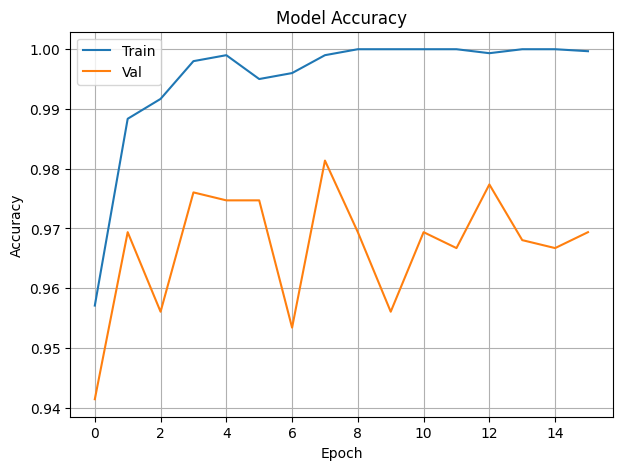

39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 522ms/step

Classification Report:
               precision    recall  f1-score   support

    glaucoma       1.00      0.92      0.96       128
      normal       0.98      1.00      0.99       488

    accuracy                           0.98       616
   macro avg       0.99      0.96      0.97       616
weighted avg       0.98      0.98      0.98       616



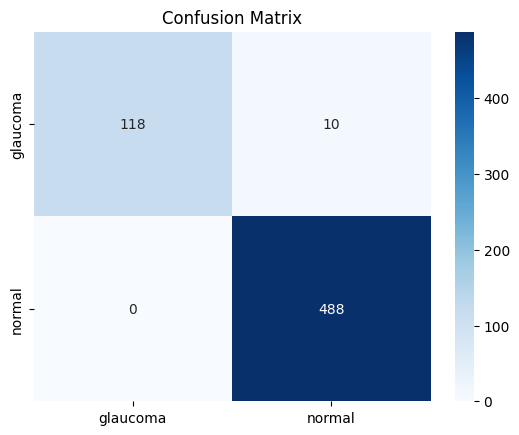

ROC-AUC: 0.9976


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


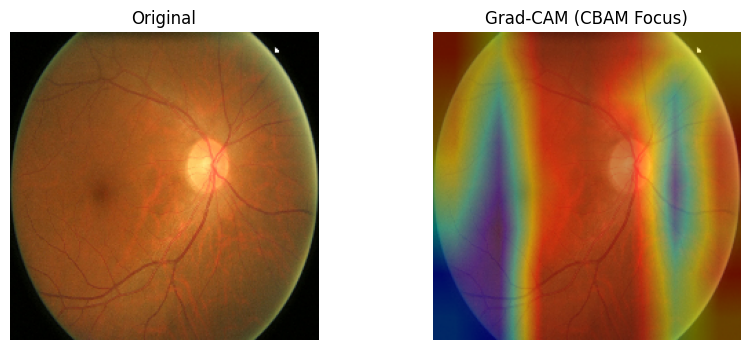

In [ ]:
# ============================================================
# 🚀 GPU-Optimized ResNet18 + CBAM for Glaucoma Classification
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, cv2

# --------------------------
# ⚙️ GPU & Mixed Precision
# --------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected: {gpus}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("⚠️ No GPU found. Training will be slow.")

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# --------------------------
# 📂 Dataset Paths
# --------------------------
train_dir = "/content/master_dataset/train"
test_dir = "/content/master_dataset/test"

# --------------------------
# 🧠 Data Generators
# --------------------------
img_size = (224, 224)
batch_size = 16

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

classes = list(train_data.class_indices.keys())
print(f"✅ Classes: {classes}")

# --------------------------
# ⚖️ Class Weights
# --------------------------
cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
cw = dict(enumerate(cw))
print(f"✅ Class weights: {cw}")

# --------------------------
# 🔧 CBAM Module (Fixed)
# --------------------------
def cbam_block(input_feature, ratio=8):
    channel = int(input_feature.shape[-1])

    # ----- Channel Attention -----
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    max_pool = layers.GlobalMaxPooling2D()(input_feature)

    shared_dense_one = layers.Dense(channel // ratio, activation='relu', kernel_initializer='he_normal')
    shared_dense_two = layers.Dense(channel, activation='sigmoid', kernel_initializer='he_normal')

    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))
    channel_attention = layers.Add()([avg_out, max_out])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)
    channel_refined = layers.Multiply()([input_feature, channel_attention])

    # ----- Spatial Attention -----
    avg_pool_spatial = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool_spatial = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)
    concat = layers.Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = layers.Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat)
    refined_feature = layers.Multiply()([channel_refined, spatial_attention])

    return refined_feature

# --------------------------
# 🧩 ResNet18 Backbone
# --------------------------
def conv_block(x, filters, stride=1):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding='same',
                      kernel_initializer='he_normal', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding='same',
                      kernel_initializer='he_normal', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride,
                                 kernel_initializer='he_normal', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

def resnet18_cbam(input_shape=(224, 224, 3), num_classes=1):
    inputs = Input(shape=input_shape)
    x = layers.Conv2D(64, 7, strides=2, padding='same',
                      kernel_initializer='he_normal', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    x = conv_block(x, 64)
    x = conv_block(x, 64)

    x = conv_block(x, 128, stride=2)
    x = conv_block(x, 128)

    x = conv_block(x, 256, stride=2)
    x = conv_block(x, 256)

    x = conv_block(x, 512, stride=2)
    x = conv_block(x, 512)

    x = cbam_block(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='sigmoid', dtype='float32')(x)
    return Model(inputs, outputs, name="ResNet18_CBAM")

# --------------------------
# 🧠 Compile & Train
# --------------------------
model = resnet18_cbam()
model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)
model.summary()

lr_reduce = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

history = model.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    class_weight=cw,
    callbacks=[lr_reduce, early_stop],
    verbose=1
)

# --------------------------
# 📈 Plot Training Curves
# --------------------------
plt.figure(figsize=(7, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'])
plt.grid(True)
plt.show()

# --------------------------
# 🧾 Evaluate on Test Set
# --------------------------
y_true = test_gen.classes
y_pred = model.predict(test_gen).ravel()
y_pred_class = (y_pred > 0.5).astype(int)

print("\nClassification Report:\n", classification_report(y_true, y_pred_class, target_names=classes))
cm = confusion_matrix(y_true, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.show()

roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC-AUC: {roc_auc:.4f}")

# --------------------------
# 🔍 Grad-CAM Visualization
# --------------------------
def get_gradcam(model, img_array, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)[0]
    conv_outputs = conv_outputs[0]

    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam = np.zeros(conv_outputs.shape[:2], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * conv_outputs[:, :, i]

    cam = np.maximum(cam, 0)
    cam /= np.max(cam) + 1e-8
    cam = np.uint8(255 * cam)
    cam = tf.image.resize(cam[..., np.newaxis], img_size).numpy().astype(np.uint8)
    return cam

# Visualize a test image
img_path = test_gen.filepaths[0]
img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
img_array = tf.keras.preprocessing.image.img_to_array(img)[np.newaxis, ...] / 255.0

cam = get_gradcam(model, img_array, "conv2d_16")  # last conv layer
heatmap = cv2.applyColorMap(cv2.cvtColor(cam, cv2.COLOR_GRAY2BGR), cv2.COLORMAP_JET)
overlay = cv2.addWeighted(np.uint8(img_array[0]*255), 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title("Grad-CAM (CBAM Focus)")
plt.axis('off')
plt.show()
